# **Análisis Exploratorio de Datos (EDA)**
# **Airbnb Listings — Ciudad de México**

Este notebook realiza un análisis exploratorio completo sobre el dataset de Airbnb listings, orientado a **regresión** con variable objetivo: **price** (precio por noche en MXN).

**Curso**: Analítica de Datos — Universidad de Antioquia  
**Profesor**: Duván Cataño  
**Laboratorio #3**

---
# 1. Librerías

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from scipy import stats

# Estilo global de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

---
# 2. Carga de Datos

In [5]:
root = Path.cwd()
if root.name == 'notebooks' and (root.parent / 'data').exists():
    project_root = root.parent
elif (root / 'data').exists():
    project_root = root
else:
    project_root = root

DATA_PATH = project_root / 'data' / 'raw' / 'dataset_regresion_listings.csv'
data = pd.read_csv(DATA_PATH, sep=',')
print(f'Dataset cargado correctamente desde: {DATA_PATH}')
print(f'Dataset cargado correctamente: {data.shape[0]:,} filas × {data.shape[1]} columnas')


Dataset cargado correctamente desde: /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/data/raw/dataset_regresion_listings.csv
Dataset cargado correctamente: 27,051 filas × 18 columnas


## 2.1 Diccionario de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | Numérica (ID) | Identificador único del listing |
| `name` | Categórica | Nombre del alojamiento |
| `host_id` | Numérica (ID) | Identificador del anfitrión |
| `host_name` | Categórica | Nombre del anfitrión |
| `neighbourhood_group` | Categórica | Grupo de vecindario (vacío en CDMX) |
| `neighbourhood` | Categórica | Alcaldía/delegación |
| `latitude` | Numérica | Latitud geográfica |
| `longitude` | Numérica | Longitud geográfica |
| `room_type` | Categórica | Tipo de habitación |
| `price` | **Numérica (TARGET)** | Precio por noche (MXN) |
| `minimum_nights` | Numérica | Mínimo de noches para reservar |
| `number_of_reviews` | Numérica | Total de reseñas |
| `last_review` | Fecha | Fecha de la última reseña |
| `reviews_per_month` | Numérica | Reseñas promedio por mes |
| `calculated_host_listings_count` | Numérica | Número de listings del anfitrión |
| `availability_365` | Numérica | Días disponibles en el año |
| `number_of_reviews_ltm` | Numérica | Reseñas en los últimos 12 meses |
| `license` | Categórica | Licencia del listing (vacío en CDMX) |

In [6]:
data.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,35797,Villa Dante,153786,Dici,NaN,Cuajimalpa de Morelos,19.38283,-99.27178,Entire home/apt,3673.0,1,0,NaN,NaN,1,363,0,NaN
1,44616,Condesa Haus,196253,Fernando,NaN,Cuauhtémoc,19.41162,-99.17794,Entire home/apt,18000.0,1,65,2025-01-01,0.38,9,360,1,NaN
2,56074,Great space in historical San Rafael,265650,Maris,NaN,Cuauhtémoc,19.43977,-99.15605,Entire home/apt,591.0,15,84,2025-02-27,0.48,1,333,1,NaN
3,67703,"2 bedroom apt. deco bldg, Condesa",334451,Nicholas,NaN,Cuauhtémoc,19.41152,-99.16857,Entire home/apt,NaN,2,50,2024-10-30,0.30,2,252,1,NaN
4,70644,Beautiful light Studio Coyoacan- full equipped !,212109,Trisha,NaN,Coyoacán,19.35448,-99.16217,Entire home/apt,NaN,3,134,2025-08-18,0.81,3,234,8,NaN
5,131610,MARIA DEL ALMA,647454,Fernando,NaN,Coyoacán,19.35416,-99.16488,Private room,NaN,1,0,NaN,NaN,3,0,0,NaN
6,165772,BEST 5 Bedroom HOUSE IN S. Miguel Chapultepec,790208,Francisco Carlos,NaN,Miguel Hidalgo,19.40826,-99.18659,Entire home/apt,3673.0,2,386,2025-08-10,2.24,5,201,28,NaN
7,171109,Cool room near WTC and Metrobus,816295,Carlos,NaN,Benito Juárez,19.39675,-99.17581,Private room,321.0,4,123,2025-09-07,0.88,2,301,15,NaN
8,180808,"Huge Luxurious Suite 70's style, perfectly loc...",36836,Roberto,NaN,Cuauhtémoc,19.42390,-99.16890,Entire home/apt,1190.0,3,62,2025-09-01,0.38,1,315,10,NaN
9,187030,Spacious apt with the best rooftop in Condesa,899360,Julian,NaN,Cuauhtémoc,19.41057,-99.17730,Entire home/apt,NaN,4,103,2023-09-08,0.61,6,0,0,NaN


In [7]:
data.tail(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
27041,1518212506886096587,Habitacion doble con baño pivado,180725654,Jose Luis,NaN,Coyoacán,19.343704,-99.123750,Private room,688.0,1,0,NaN,NaN,9,365,0,NaN
27042,1518220076513599673,Renta de habitacion/ espacio libre para trabajar.,720844507,Lorena,NaN,Cuauhtémoc,19.422310,-99.151020,Private room,457.0,1,0,NaN,NaN,1,365,0,NaN
27043,1518257575420839432,Stay in Roma Norte's 2BR/2BA apt with Red Kitchen,355750680,Rodrigo,NaN,Cuauhtémoc,19.416000,-99.156560,Entire home/apt,2915.0,1,0,NaN,NaN,13,365,0,NaN
27044,1518294402303464625,Casa Providencia SIETE 3B / 2 B,10802698,Hector Alexis,NaN,Benito Juárez,19.385283,-99.170555,Entire home/apt,2479.0,2,0,NaN,NaN,4,262,0,NaN
27045,1518348422274177191,"Hermoso, cómodo, silencioso y cercano a todo.",188587763,Diego,NaN,Miguel Hidalgo,19.456776,-99.175187,Entire home/apt,811.0,1,0,NaN,NaN,1,347,0,NaN
27046,1518356968266486778,Suite Frida,674644167,Heyliana,NaN,Venustiano Carranza,19.442240,-99.113440,Private room,1096.0,1,0,NaN,NaN,5,365,0,NaN
27047,1518388105556721163,Habitación a un costado de Ciudad Universitaria,222854336,Marco Antonio,NaN,Coyoacán,19.308017,-99.168158,Private room,260.0,1,0,NaN,NaN,1,365,0,NaN
27048,1518433354720281854,Espacioso departamento en Anzures,470800231,Hector Fernando,NaN,Miguel Hidalgo,19.434460,-99.174010,Entire home/apt,996.0,1,0,NaN,NaN,20,365,0,NaN
27049,1518462568893975567,Casa Roma Baja 05,710857718,Camila,NaN,Cuauhtémoc,19.406435,-99.160934,Entire home/apt,458.0,1,0,NaN,NaN,7,363,0,NaN
27050,1518561444972990747,Departamento con Terraza privada Roma Norte,362149590,Ilse,NaN,Cuauhtémoc,19.413682,-99.154815,Entire home/apt,3082.0,1,0,NaN,NaN,4,365,0,NaN


In [8]:
data.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'license']

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27051 non-null  int64  
 1   name                            27051 non-null  str    
 2   host_id                         27051 non-null  int64  
 3   host_name                       27045 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   27051 non-null  str    
 6   latitude                        27051 non-null  float64
 7   longitude                       27051 non-null  float64
 8   room_type                       27051 non-null  str    
 9   price                           23567 non-null  float64
 10  minimum_nights                  27051 non-null  int64  
 11  number_of_reviews               27051 non-null  int64  
 12  last_review                     23650 non-n

---
# 3. Identificación de Tipos de Variables

In [10]:
# Separar variables por tipo
vars_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
vars_categoricas = data.select_dtypes(include=['object']).columns.tolist()

# Excluir IDs y columnas vacías del análisis sustantivo
vars_id = ['id', 'host_id']
vars_vacias = ['neighbourhood_group', 'license']  # 100% nulos
vars_fecha = ['last_review']

vars_num_analisis = [v for v in vars_numericas if v not in vars_id + ['neighbourhood_group', 'license']]
vars_cat_analisis = [v for v in vars_categoricas if v not in vars_vacias + vars_fecha + ['name', 'host_name']]

print('--- Variables numéricas para análisis ---')
print(vars_num_analisis)
print('\n--- Variables categóricas para análisis ---')
print(vars_cat_analisis)
print('\n--- Variables excluidas (IDs, vacías, fecha, texto libre) ---')
print(vars_id + vars_vacias + vars_fecha + ['name', 'host_name'])

--- Variables numéricas para análisis ---
['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

--- Variables categóricas para análisis ---
['neighbourhood', 'room_type']

--- Variables excluidas (IDs, vacías, fecha, texto libre) ---
['id', 'host_id', 'neighbourhood_group', 'license', 'last_review', 'name', 'host_name']


---
# 4. Análisis Descriptivo

In [11]:
# Estadísticas descriptivas variables numéricas
data[vars_num_analisis].describe().round(2)

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,27051.00,27051.00,23567.00,27051.00,27051.00,23650.00,27051.00,27051.00,27051.00
mean,19.41,-99.17,1792.54,4.58,53.78,1.85,14.56,232.69,15.69
std,0.04,0.03,13230.94,24.78,85.14,2.28,31.89,122.27,23.62
min,19.18,-99.34,61.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,19.39,-99.18,643.00,1.00,4.00,0.45,1.00,140.00,0.00
50%,19.42,-99.17,1039.00,2.00,21.00,1.26,3.00,269.00,7.00
75%,19.43,-99.15,1611.00,2.00,69.00,2.62,11.00,341.00,23.00
max,19.56,-98.96,900000.00,1125.00,1434.00,119.46,221.00,365.00,665.00


In [12]:
# Medidas adicionales: mediana, skewness, kurtosis
desc_extra = pd.DataFrame({
    'media': data[vars_num_analisis].mean(),
    'mediana': data[vars_num_analisis].median(),
    'desv_std': data[vars_num_analisis].std(),
    'skewness': data[vars_num_analisis].skew(),
    'kurtosis': data[vars_num_analisis].kurtosis()
}).round(3)
print(desc_extra)

                                   media   mediana   desv_std  skewness  \
latitude                          19.405    19.415      0.042    -1.412   
longitude                        -99.165   -99.167      0.034     0.199   
price                           1792.541  1039.000  13230.941    52.125   
minimum_nights                     4.581     2.000     24.785    16.549   
number_of_reviews                 53.778    21.000     85.143     3.516   
reviews_per_month                  1.855     1.260      2.281    10.202   
calculated_host_listings_count    14.560     3.000     31.892     4.096   
availability_365                 232.686   269.000    122.271    -0.680   
number_of_reviews_ltm             15.691     7.000     23.616     6.017   

                                kurtosis  
latitude                           2.918  
longitude                          3.942  
price                           2998.945  
minimum_nights                   368.475  
number_of_reviews                 

In [13]:
# Variable objetivo: price
print('=== Análisis de la Variable Objetivo: price ===')
p = data['price'].dropna()
print(f'Media:             ${p.mean():>12,.2f} MXN')
print(f'Mediana:           ${p.median():>12,.2f} MXN')
print(f'Desv. Estándar:    ${p.std():>12,.2f} MXN')
print(f'Mínimo:            ${p.min():>12,.2f} MXN')
print(f'Máximo:            ${p.max():>12,.2f} MXN')
print(f'Asimetría (skew):  {p.skew():>15.3f}')
print(f'Kurtosis:          {p.kurtosis():>15.3f}')
print(f'\nObservaciones con precio:  {p.count():,} / {len(data):,} ({p.count()/len(data)*100:.1f}%)')

=== Análisis de la Variable Objetivo: price ===
Media:             $    1,792.54 MXN
Mediana:           $    1,039.00 MXN
Desv. Estándar:    $   13,230.94 MXN
Mínimo:            $       61.00 MXN
Máximo:            $  900,000.00 MXN
Asimetría (skew):           52.125
Kurtosis:                 2998.945

Observaciones con precio:  23,567 / 27,051 (87.1%)


---
# 5. Identificación de Valores Faltantes

                                nulos  porcentaje
license                         27051      100.00
neighbourhood_group             27051      100.00
price                            3484       12.88
reviews_per_month                3401       12.57
last_review                      3401       12.57
host_name                           6        0.02
name                                0        0.00
id                                  0        0.00
neighbourhood                       0        0.00
host_id                             0        0.00
room_type                           0        0.00
longitude                           0        0.00
latitude                            0        0.00
number_of_reviews                   0        0.00
minimum_nights                      0        0.00
calculated_host_listings_count      0        0.00
availability_365                    0        0.00
number_of_reviews_ltm               0        0.00


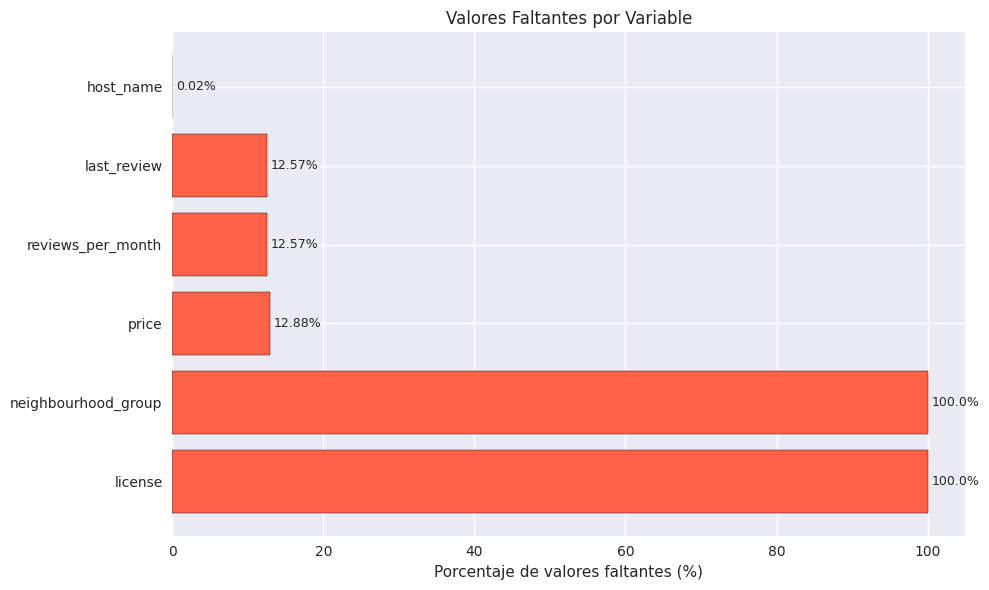

In [14]:
# Resumen de valores nulos
nulos = pd.DataFrame({
    'nulos': data.isnull().sum(),
    'porcentaje': (data.isnull().sum() / len(data) * 100).round(2)
}).sort_values('porcentaje', ascending=False)
print(nulos)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
cols_con_nulos = nulos[nulos['nulos'] > 0].index.tolist()
ax.barh(cols_con_nulos, nulos.loc[cols_con_nulos, 'porcentaje'], color='tomato', edgecolor='black')
ax.set_xlabel('Porcentaje de valores faltantes (%)')
ax.set_title('Valores Faltantes por Variable')
for i, (col, row) in enumerate(nulos[nulos['nulos'] > 0].iterrows()):
    ax.text(row['porcentaje'] + 0.5, i, f"{row['porcentaje']}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Observaciones:**
- `neighbourhood_group` y `license`: **100% nulos** → columnas vacías, se eliminan del análisis.
- `price`: ~12.9% nulos → variable objetivo, requiere imputación o eliminación según el modelo.
- `last_review` y `reviews_per_month`: ~12.6% nulos → listings sin ninguna reseña registrada (correlacionados).
- `host_name`: <0.1% nulos → imputación simple.

---
# 6. Distribuciones Univariadas (Histogramas)

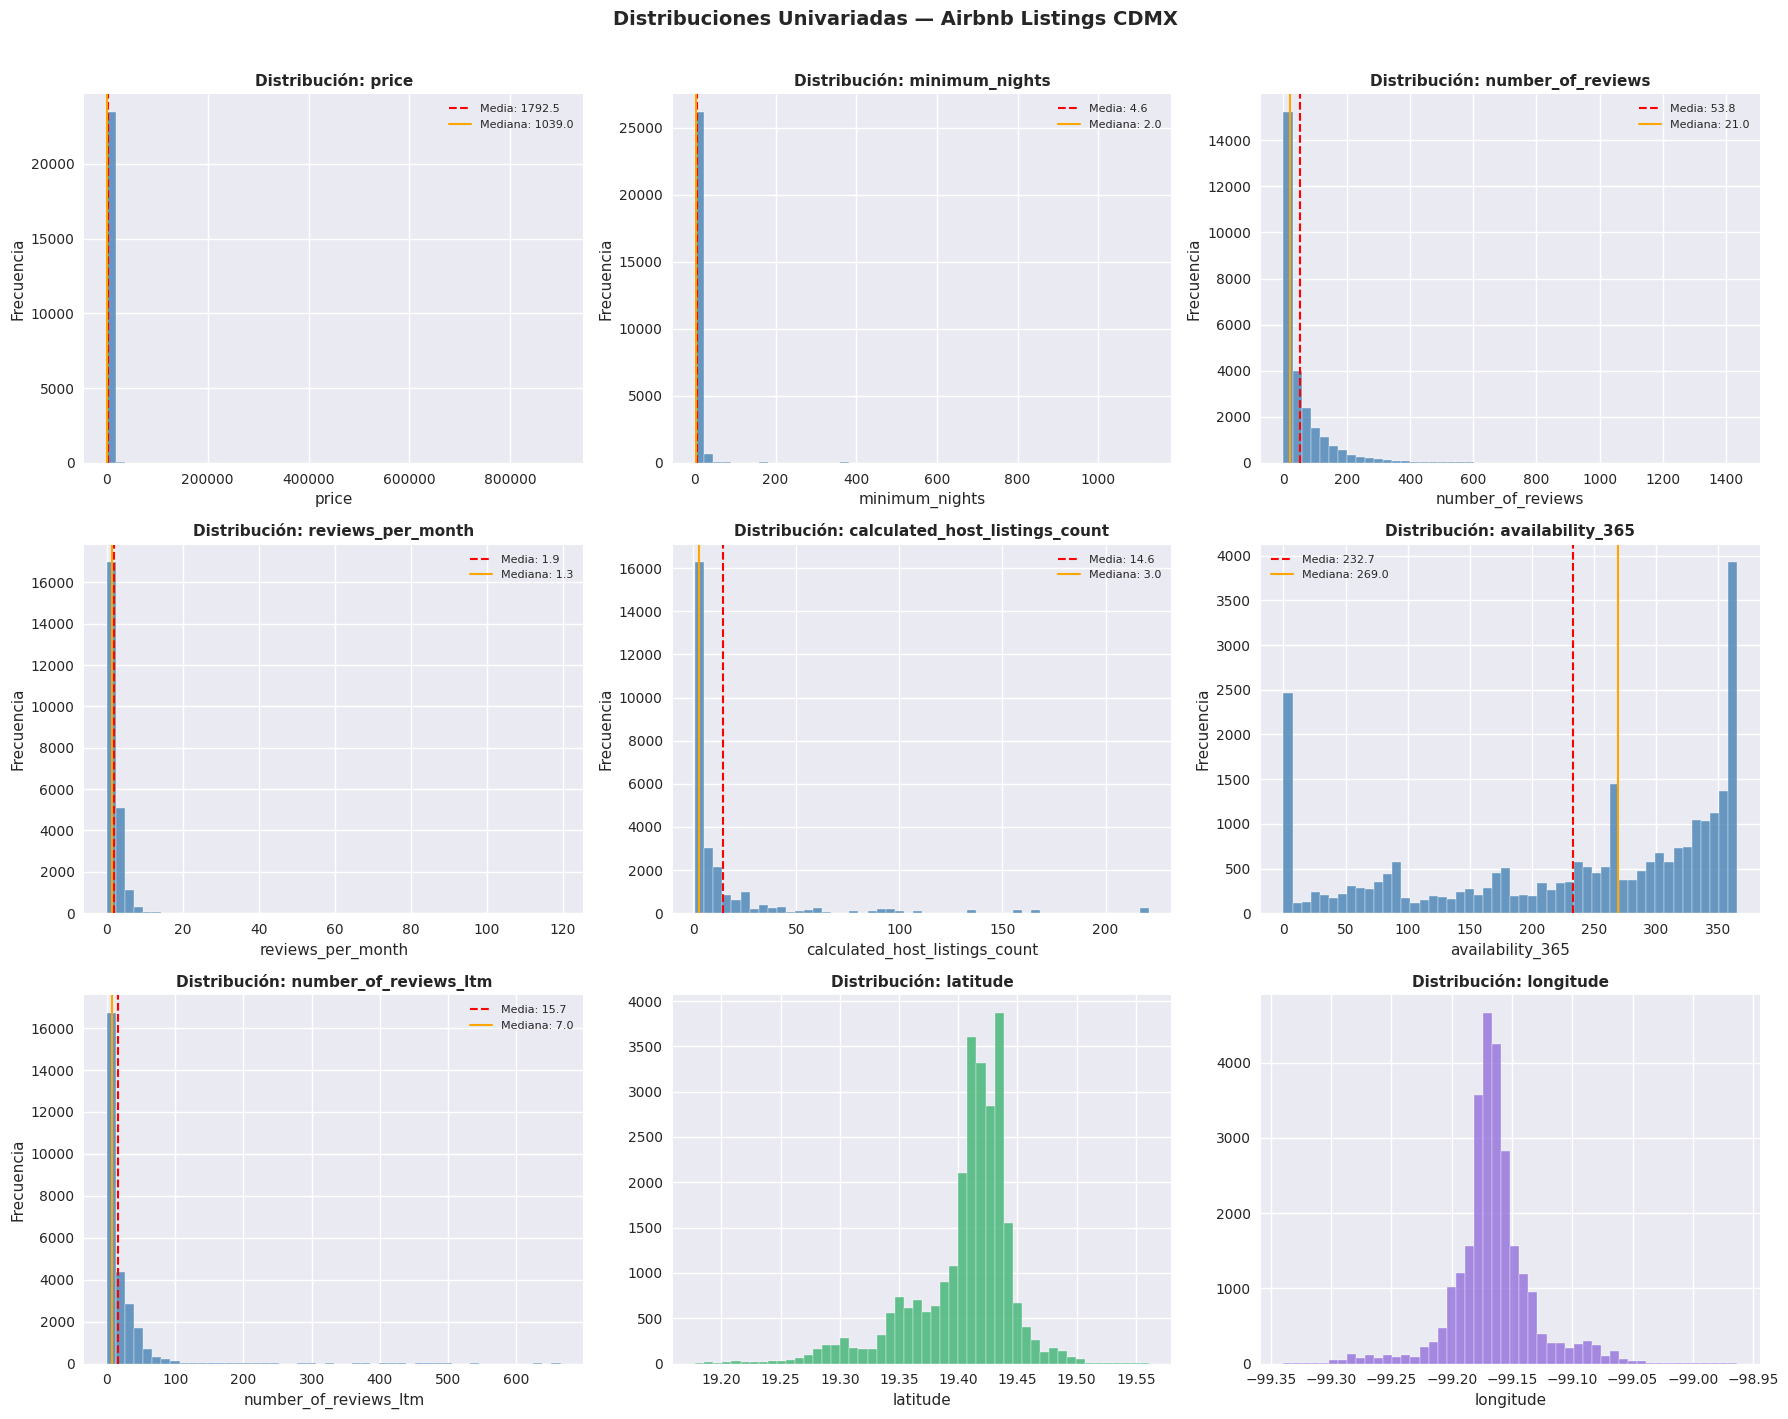

In [15]:
# Histogramas de variables numéricas (sin price aún — se ve después con detalle)
vars_hist = ['price', 'minimum_nights', 'number_of_reviews',
             'reviews_per_month', 'calculated_host_listings_count',
             'availability_365', 'number_of_reviews_ltm']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, var in enumerate(vars_hist):
    col = data[var].dropna()
    axes[i].hist(col, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribución: {var}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(col.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {col.mean():.1f}')
    axes[i].axvline(col.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana: {col.median():.1f}')
    axes[i].legend(fontsize=8)

# Histograma geográfico (latitude y longitude)
axes[7].hist(data['latitude'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[7].set_title('Distribución: latitude', fontsize=11, fontweight='bold')
axes[7].set_xlabel('latitude')
axes[8].hist(data['longitude'], bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[8].set_title('Distribución: longitude', fontsize=11, fontweight='bold')
axes[8].set_xlabel('longitude')

plt.suptitle('Distribuciones Univariadas — Airbnb Listings CDMX', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

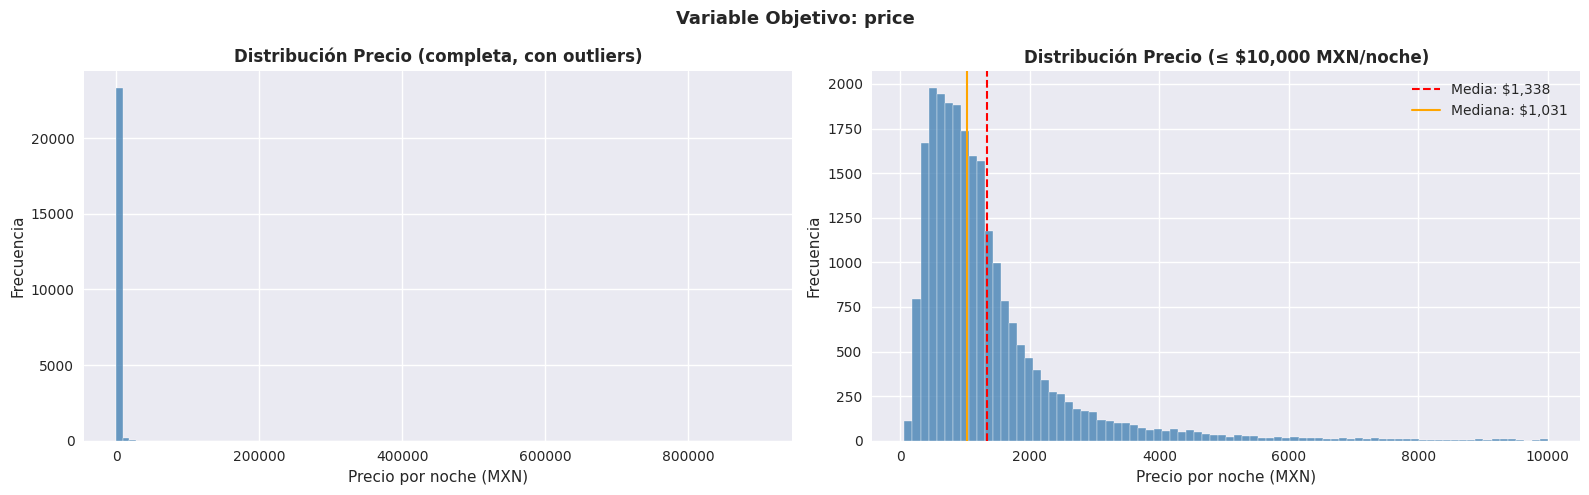

Nota: La distribución del precio es fuertemente sesgada a la derecha (skew = 52.12).
La media ($1,793) es mucho mayor que la mediana ($1,039) debido a los valores extremos.


In [16]:
# Distribución del precio filtrada (sin outliers extremos) para mejor visualización
price_filtrado = data['price'][data['price'] <= 10000].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma precio completo
axes[0].hist(data['price'].dropna(), bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución Precio (completa, con outliers)', fontweight='bold')
axes[0].set_xlabel('Precio por noche (MXN)')
axes[0].set_ylabel('Frecuencia')

# Histograma precio recortado
axes[1].hist(price_filtrado, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(price_filtrado.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: ${price_filtrado.mean():,.0f}')
axes[1].axvline(price_filtrado.median(), color='orange', linestyle='-', linewidth=1.5, label=f'Mediana: ${price_filtrado.median():,.0f}')
axes[1].set_title('Distribución Precio (≤ $10,000 MXN/noche)', fontweight='bold')
axes[1].set_xlabel('Precio por noche (MXN)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Variable Objetivo: price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Nota: La distribución del precio es fuertemente sesgada a la derecha (skew = {data["price"].skew():.2f}).')
print(f'La media (${data["price"].mean():,.0f}) es mucho mayor que la mediana (${data["price"].median():,.0f}) debido a los valores extremos.')

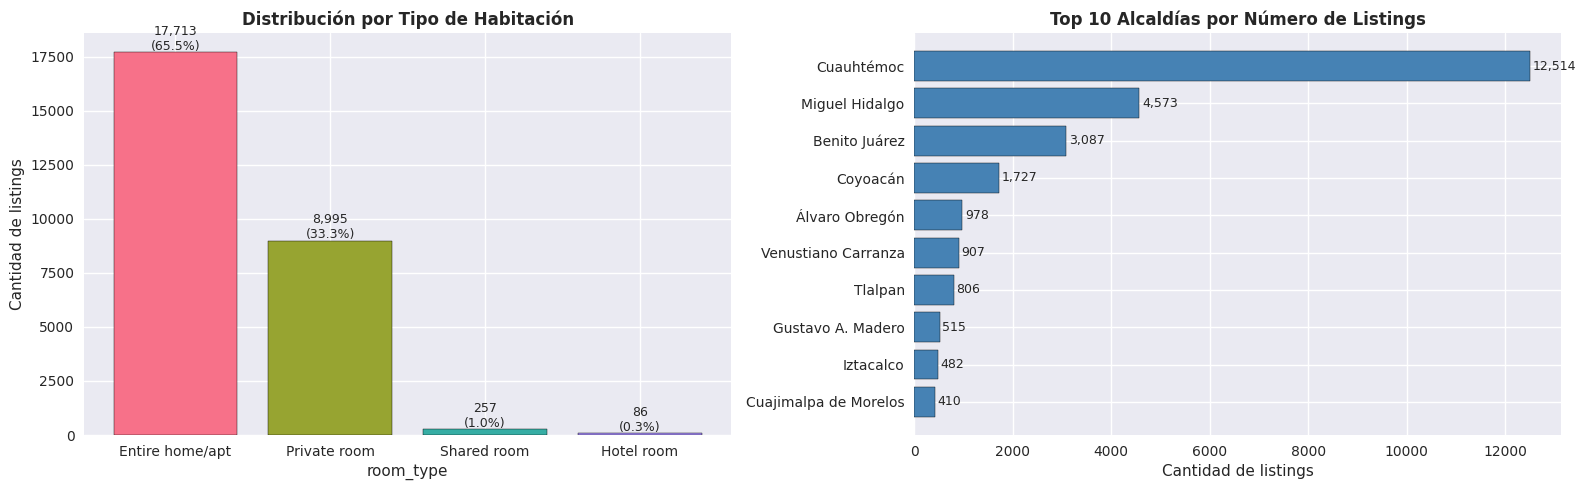

In [17]:
# Distribución de variables categóricas clave
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Room type
rt_counts = data['room_type'].value_counts()
axes[0].bar(rt_counts.index, rt_counts.values, color=sns.color_palette('husl', len(rt_counts)), edgecolor='black')
axes[0].set_title('Distribución por Tipo de Habitación', fontweight='bold')
axes[0].set_xlabel('room_type')
axes[0].set_ylabel('Cantidad de listings')
for i, (v) in enumerate(rt_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(data)*100:.1f}%)', ha='center', fontsize=9)

# Neighbourhood (top 10)
top_nb = data['neighbourhood'].value_counts().head(10)
axes[1].barh(top_nb.index[::-1], top_nb.values[::-1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Alcaldías por Número de Listings', fontweight='bold')
axes[1].set_xlabel('Cantidad de listings')
for i, v in enumerate(top_nb.values[::-1]):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
# 7. Identificación de Valores Atípicos (Outliers)

In [18]:
# Método IQR para detección de outliers
def calcular_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'lower': lower, 'upper': upper,
            'n_outliers': len(outliers), 'pct_outliers': len(outliers)/len(serie)*100}

vars_outlier = ['price', 'minimum_nights', 'number_of_reviews',
                'reviews_per_month', 'calculated_host_listings_count',
                'availability_365', 'number_of_reviews_ltm']

resumen_outliers = pd.DataFrame({
    v: calcular_outliers_iqr(data[v].dropna()) for v in vars_outlier
}).T.round(2)
print(resumen_outliers)

                                    Q1       Q3     IQR  lower    upper  \
price                           643.00  1611.00  968.00 -809.0  3063.00   
minimum_nights                    1.00     2.00    1.00   -0.5     3.50   
number_of_reviews                 4.00    69.00   65.00  -93.5   166.50   
reviews_per_month                 0.45     2.62    2.17   -2.8     5.88   
calculated_host_listings_count    1.00    11.00   10.00  -14.0    26.00   
availability_365                140.00   341.00  201.00 -161.5   642.50   
number_of_reviews_ltm             0.00    23.00   23.00  -34.5    57.50   

                                n_outliers  pct_outliers  
price                               1768.0          7.50  
minimum_nights                      3429.0         12.68  
number_of_reviews                   2193.0          8.11  
reviews_per_month                    899.0          3.80  
calculated_host_listings_count      3246.0         12.00  
availability_365                       0.0   

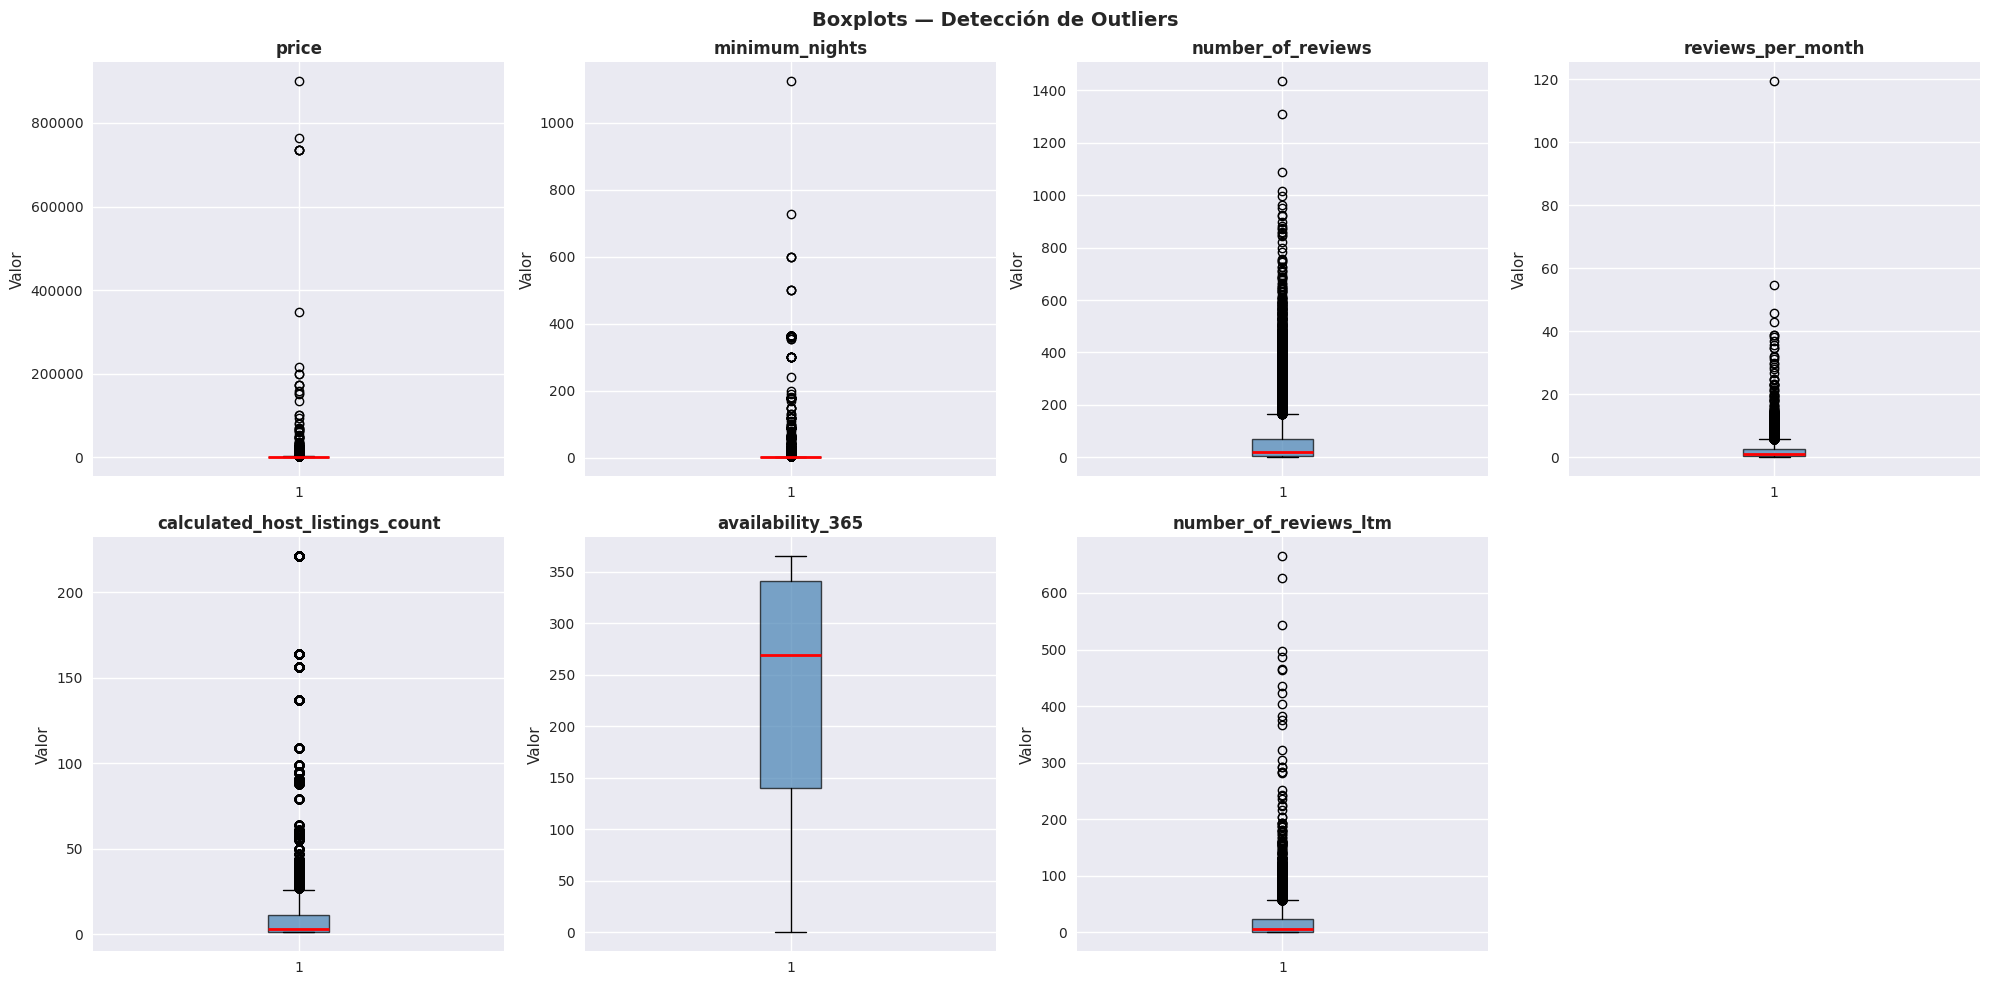

In [19]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, var in enumerate(vars_outlier):
    axes[i].boxplot(data[var].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{var}', fontweight='bold')
    axes[i].set_ylabel('Valor')

axes[7].axis('off')
plt.suptitle('Boxplots — Detección de Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Casos extremos de precio
print('Top 10 listings más caros:')
print(data[['name', 'neighbourhood', 'room_type', 'price', 'minimum_nights']]
      .nlargest(10, 'price').to_string(index=False))

print('\nListings con precio < $200 MXN/noche:')
print(data[data['price'] < 200][['name', 'neighbourhood', 'room_type', 'price']].head(10).to_string(index=False))

Top 10 listings más caros:
                                              name  neighbourhood       room_type    price  minimum_nights
                 ¡Recámara acogedora y muy cómoda!        Tlalpan    Private room 900000.0               1
 Casa Mexicana rodeada de árboles cerca de Sta. Fe Álvaro Obregón    Private room 765000.0               4
    Pets Welcome, Spa - Near El Pendulo Bookstore!     Cuauhtémoc      Hotel room 734464.0               1
3 Std King Rooms w/ Spa - Steps from Parque México     Cuauhtémoc      Hotel room 734464.0               1
      Mexico City Luxury Oasis with Pool | 2 Units     Cuauhtémoc      Hotel room 734464.0               1
  Artistic Retreat in Heart of Condesa w/ Shuttle!     Cuauhtémoc    Private room 734464.0               1
  4 Thoughtfully curated Villas / Heart of Condesa     Cuauhtémoc Entire home/apt 347429.0               3
                     3 Thoughtfully curated Villas     Cuauhtémoc Entire home/apt 217143.0               3
          

---
# 8. Análisis de Correlación

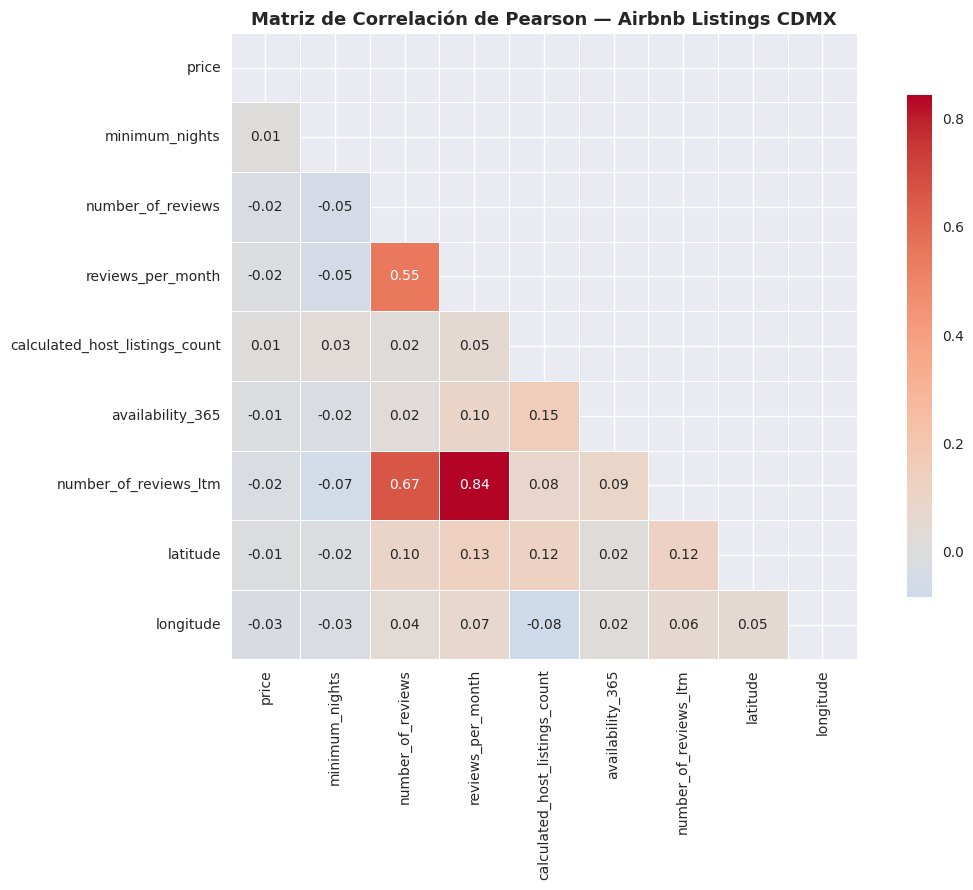

In [21]:
# Matriz de correlación de Pearson
vars_corr = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'calculated_host_listings_count', 'availability_365',
             'number_of_reviews_ltm', 'latitude', 'longitude']

corr_matrix = data[vars_corr].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación de Pearson — Airbnb Listings CDMX', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Correlación de Pearson con price (ordenado por magnitud):
longitude                        -0.0298
number_of_reviews_ltm            -0.0249
number_of_reviews                -0.0231
reviews_per_month                -0.0178
minimum_nights                    0.0128
availability_365                 -0.0122
calculated_host_listings_count    0.0091
latitude                         -0.0057
Name: price, dtype: float64


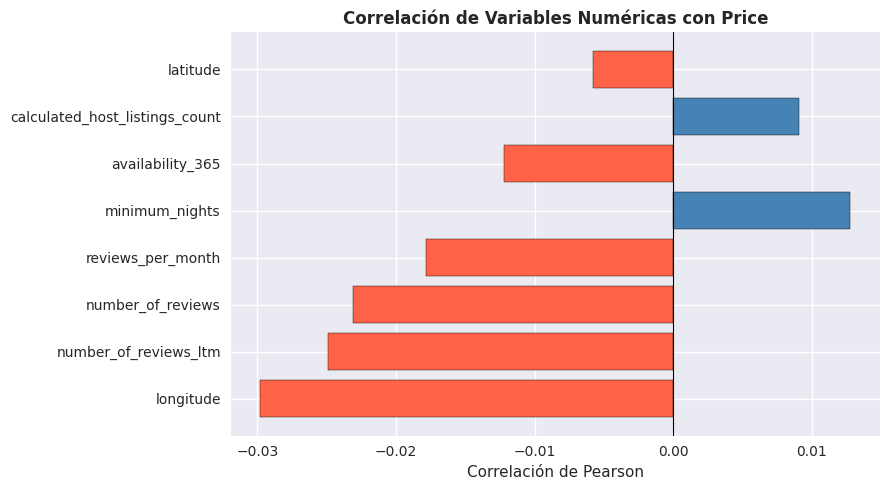

In [22]:
# Correlación específica con la variable objetivo: price
corr_con_price = corr_matrix['price'].drop('price').sort_values(key=abs, ascending=False)
print('Correlación de Pearson con price (ordenado por magnitud):')
print(corr_con_price.round(4))

# Visualización
plt.figure(figsize=(9, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_con_price]
plt.barh(corr_con_price.index, corr_con_price.values, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlación de Pearson')
plt.title('Correlación de Variables Numéricas con Price', fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Correlación de Spearman (más robusta ante outliers y no linealidad)
corr_spearman = data[vars_corr].corr(method='spearman')['price'].drop('price').sort_values(key=abs, ascending=False)
print('Correlación de Spearman con price:')
print(corr_spearman.round(4))

# Comparativa Pearson vs Spearman
comp = pd.DataFrame({'Pearson': corr_con_price, 'Spearman': corr_spearman}).round(4)
print('\nComparativa Pearson vs Spearman:')
print(comp)

Correlación de Spearman con price:
longitude                        -0.2411
calculated_host_listings_count    0.1205
latitude                          0.0993
availability_365                 -0.0614
reviews_per_month                 0.0539
number_of_reviews_ltm             0.0152
number_of_reviews                -0.0054
minimum_nights                    0.0051
Name: price, dtype: float64

Comparativa Pearson vs Spearman:
                                Pearson  Spearman
availability_365                -0.0122   -0.0614
calculated_host_listings_count   0.0091    0.1205
latitude                        -0.0057    0.0993
longitude                       -0.0298   -0.2411
minimum_nights                   0.0128    0.0051
number_of_reviews               -0.0231   -0.0054
number_of_reviews_ltm           -0.0249    0.0152
reviews_per_month               -0.0178    0.0539


---
# 9. Análisis de Relaciones entre Variables — Scatter Plots

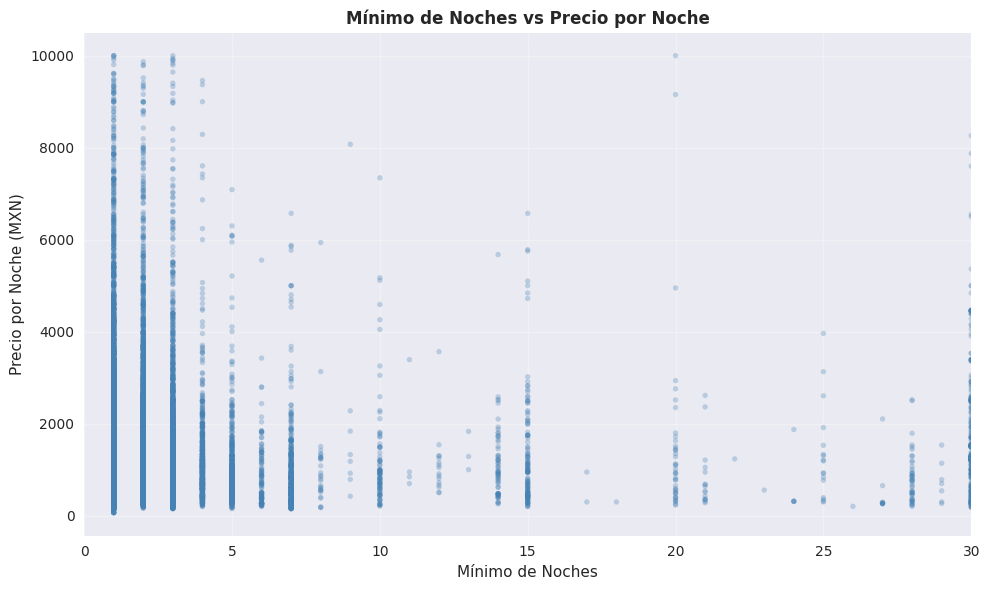

In [24]:
# Scatter: minimum_nights vs price
data_plot = data[data['price'] <= 10000].dropna(subset=['price', 'minimum_nights'])

plt.figure(figsize=(10, 6))
plt.scatter(data_plot['minimum_nights'], data_plot['price'],
            alpha=0.3, color='steelblue', s=15, edgecolors='none')
plt.xlabel('Mínimo de Noches')
plt.ylabel('Precio por Noche (MXN)')
plt.title('Mínimo de Noches vs Precio por Noche', fontweight='bold')
plt.xlim(0, 30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

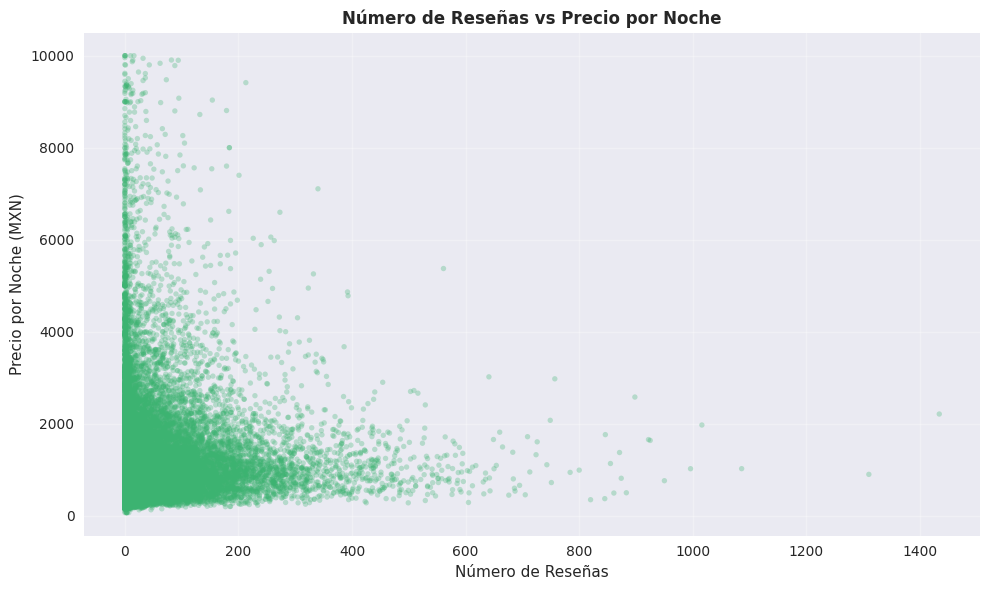

In [25]:
# Scatter: number_of_reviews vs price
plt.figure(figsize=(10, 6))
plt.scatter(data_plot['number_of_reviews'], data_plot['price'],
            alpha=0.3, color='mediumseagreen', s=15, edgecolors='none')
plt.xlabel('Número de Reseñas')
plt.ylabel('Precio por Noche (MXN)')
plt.title('Número de Reseñas vs Precio por Noche', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

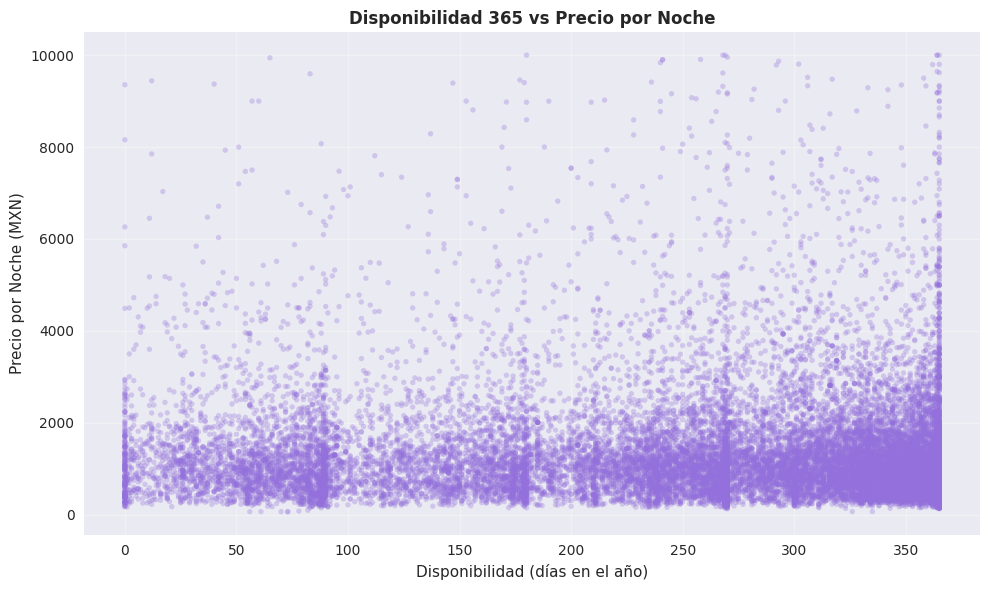

In [26]:
# Scatter: availability_365 vs price
plt.figure(figsize=(10, 6))
plt.scatter(data_plot['availability_365'], data_plot['price'],
            alpha=0.3, color='mediumpurple', s=15, edgecolors='none')
plt.xlabel('Disponibilidad (días en el año)')
plt.ylabel('Precio por Noche (MXN)')
plt.title('Disponibilidad 365 vs Precio por Noche', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

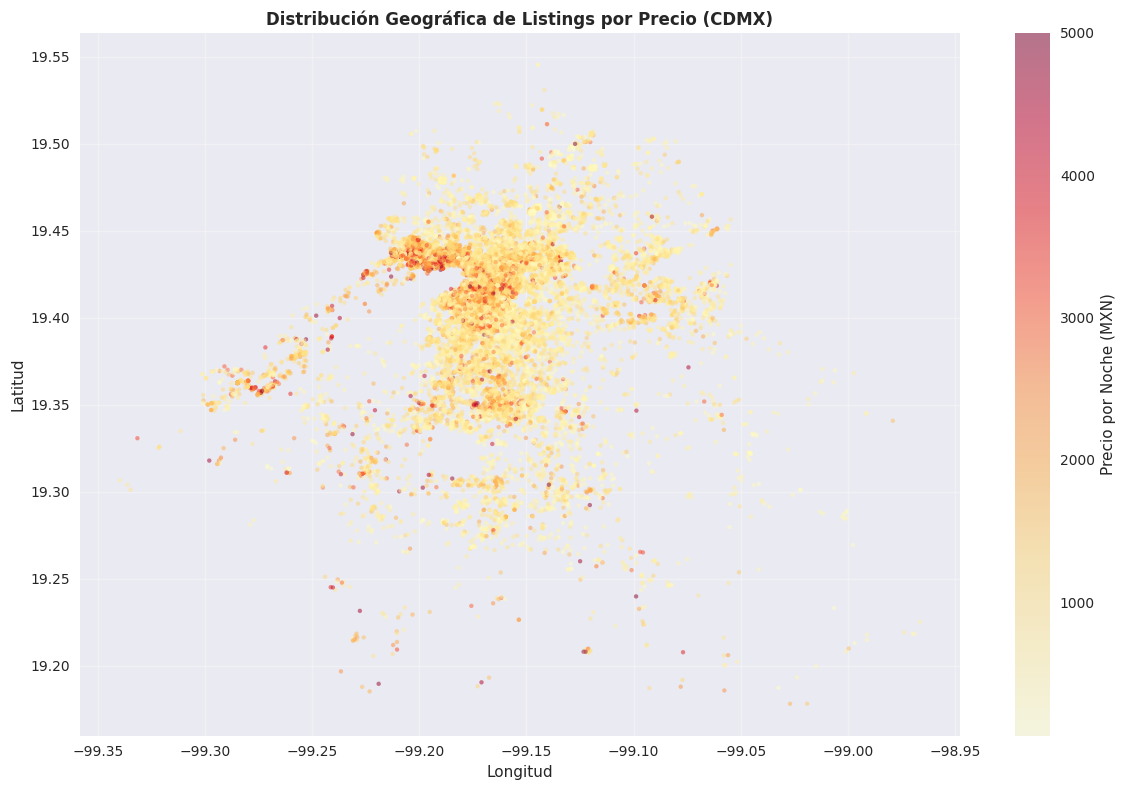

In [27]:
# Scatter: ubicación geográfica coloreada por precio
data_geo = data.dropna(subset=['price', 'latitude', 'longitude'])
data_geo = data_geo[data_geo['price'] <= 5000]  # filtrar outliers extremos

plt.figure(figsize=(12, 8))
sc = plt.scatter(data_geo['longitude'], data_geo['latitude'],
                 c=data_geo['price'], cmap='YlOrRd', alpha=0.5, s=10, edgecolors='none')
plt.colorbar(sc, label='Precio por Noche (MXN)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución Geográfica de Listings por Precio (CDMX)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 10. Análisis por Variables Categóricas

In [28]:
# Precio por tipo de habitación
print('Precio promedio y mediano por tipo de habitación:')
print(data.groupby('room_type')['price']
      .agg(['count', 'mean', 'median', 'std'])
      .rename(columns={'count': 'listings', 'mean': 'media', 'median': 'mediana', 'std': 'desv_std'})
      .round(0))

Precio promedio y mediano por tipo de habitación:
                 listings    media  mediana  desv_std
room_type                                            
Entire home/apt     15896   1930.0   1250.0    5922.0
Hotel room             57  42841.0   2000.0  164543.0
Private room         7360   1227.0    580.0   16288.0
Shared room           254    361.0    261.0     819.0


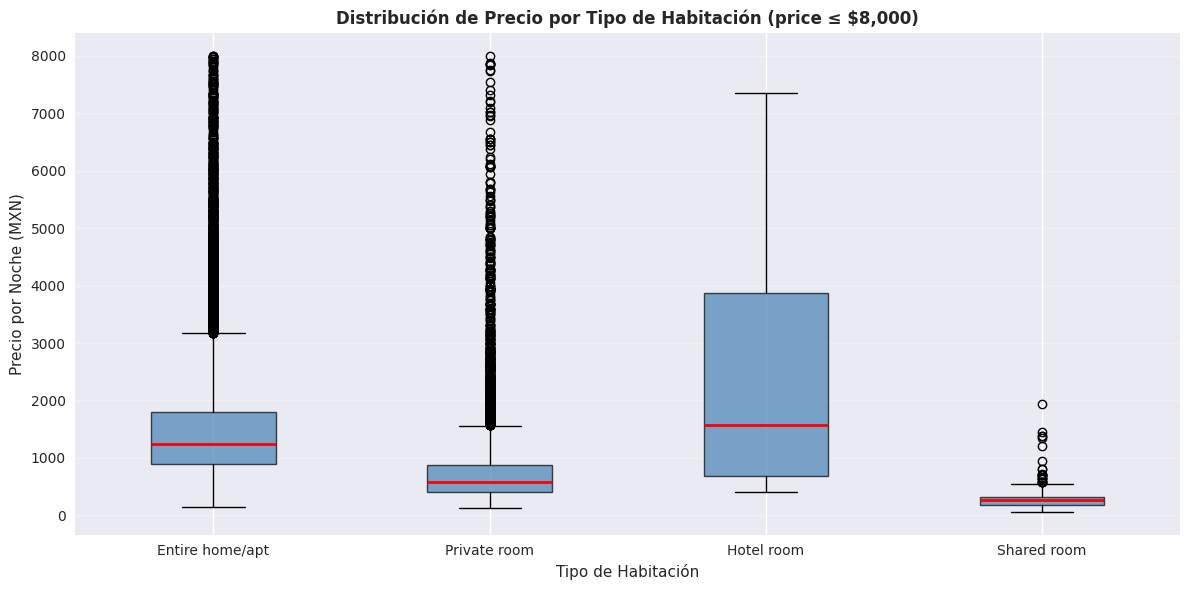

In [29]:
# Boxplot: precio por tipo de habitación
data_box = data[data['price'] <= 8000].dropna(subset=['price'])

plt.figure(figsize=(12, 6))
room_types = data_box['room_type'].unique()
datos_por_tipo = [data_box[data_box['room_type'] == rt]['price'].values for rt in room_types]
plt.boxplot(datos_por_tipo, labels=room_types, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio por Noche (MXN)')
plt.title('Distribución de Precio por Tipo de Habitación (price ≤ $8,000)', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Precio promedio por alcaldía (mín. 50 listings):
                          mean  median  count
neighbourhood                                
Tlalpan                 2493.0   638.0    626
Cuajimalpa de Morelos   2151.0  1286.0    349
Cuauhtémoc              2126.0  1185.0  11253
Álvaro Obregón          2118.0   900.0    812
Miguel Hidalgo          1876.0  1301.0   3979
Coyoacán                1245.0   794.0   1415
La Magdalena Contreras  1195.0   790.0    108
Benito Juárez           1120.0   811.0   2528
Xochimilco              1114.0   617.0    120
Iztacalco                930.0   745.0    441
Venustiano Carranza      846.0   682.0    816
Gustavo A. Madero        821.0   552.0    459
Iztapalapa               753.0   543.0    261
Azcapotzalco             708.0   512.0    344


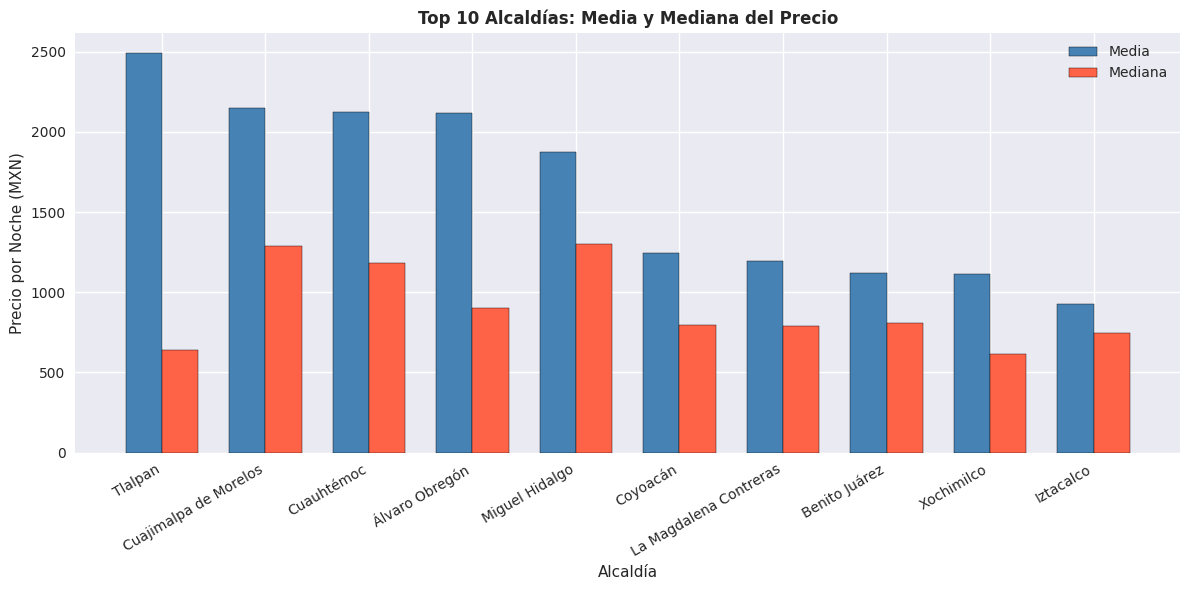

In [30]:
# Precio promedio por alcaldía (top 10)
precio_alcaldia = data.groupby('neighbourhood')['price'].agg(['mean', 'median', 'count'])
precio_alcaldia = precio_alcaldia[precio_alcaldia['count'] >= 50].sort_values('mean', ascending=False)
print('Precio promedio por alcaldía (mín. 50 listings):')
print(precio_alcaldia.round(0).to_string())

top10 = precio_alcaldia.head(10)
plt.figure(figsize=(12, 6))
x = range(len(top10))
width = 0.35
plt.bar([i - width/2 for i in x], top10['mean'], width, label='Media', color='steelblue', edgecolor='black')
plt.bar([i + width/2 for i in x], top10['median'], width, label='Mediana', color='tomato', edgecolor='black')
plt.xticks(x, top10.index, rotation=30, ha='right')
plt.xlabel('Alcaldía')
plt.ylabel('Precio por Noche (MXN)')
plt.title('Top 10 Alcaldías: Media y Mediana del Precio', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
# 11. Pruebas Estadísticas de Asociación

In [31]:
# ANOVA: ¿Hay diferencia significativa de precio entre room_types?
from scipy.stats import f_oneway, kruskal

grupos_rt = [data[data['room_type'] == rt]['price'].dropna() for rt in data['room_type'].unique()]
f_stat, p_anova = f_oneway(*grupos_rt)
h_stat, p_kruskal = kruskal(*grupos_rt)

print('=== Prueba ANOVA — Precio por Tipo de Habitación ===')
print(f'F-estadístico: {f_stat:.4f}')
print(f'p-valor:       {p_anova:.6f}')
print(f'Conclusión:    {"Se rechaza H0 → hay diferencias significativas de precio entre tipos" if p_anova < 0.05 else "No se rechaza H0"}')

print('\n=== Prueba Kruskal-Wallis (no paramétrica) ===')
print(f'H-estadístico: {h_stat:.4f}')
print(f'p-valor:       {p_kruskal:.6f}')
print(f'Conclusión:    {"Se rechaza H0 → distribuciones de precio difieren entre tipos" if p_kruskal < 0.05 else "No se rechaza H0"}')

=== Prueba ANOVA — Precio por Tipo de Habitación ===
F-estadístico: 193.5663
p-valor:       0.000000
Conclusión:    Se rechaza H0 → hay diferencias significativas de precio entre tipos

=== Prueba Kruskal-Wallis (no paramétrica) ===
H-estadístico: 6341.3407
p-valor:       0.000000
Conclusión:    Se rechaza H0 → distribuciones de precio difieren entre tipos


In [32]:
# Pearson y Spearman — Correlaciones con precio y sus p-valores
print('Correlaciones con price (Pearson y Spearman) + p-valor:')
print(f'{"Variable":<35} {"Pearson r":>10} {"p Pearson":>12} {"Spearman r":>12} {"p Spearman":>12}')
print('-'*85)

vars_test = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'calculated_host_listings_count', 'availability_365',
             'number_of_reviews_ltm', 'latitude', 'longitude']

for var in vars_test:
    df_pair = data[['price', var]].dropna()
    r_p, pv_p = stats.pearsonr(df_pair['price'], df_pair[var])
    r_s, pv_s = stats.spearmanr(df_pair['price'], df_pair[var])
    sig_p = '***' if pv_p < 0.001 else ('**' if pv_p < 0.01 else ('*' if pv_p < 0.05 else ''))
    sig_s = '***' if pv_s < 0.001 else ('**' if pv_s < 0.01 else ('*' if pv_s < 0.05 else ''))
    print(f'{var:<35} {r_p:>10.4f} {pv_p:>12.4e}{sig_p:<3} {r_s:>12.4f} {pv_s:>12.4e}{sig_s}')

print('\nSignificancia: *** p<0.001  ** p<0.01  * p<0.05')

Correlaciones con price (Pearson y Spearman) + p-valor:
Variable                             Pearson r    p Pearson   Spearman r   p Spearman
-------------------------------------------------------------------------------------
minimum_nights                          0.0128   4.9369e-02*         0.0051   4.3124e-01
number_of_reviews                      -0.0231   3.9308e-04***      -0.0054   4.0324e-01
reviews_per_month                      -0.0178   9.8092e-03**        0.0539   5.2570e-15***
calculated_host_listings_count          0.0091   1.6346e-01          0.1205   6.2325e-77***
availability_365                       -0.0122   6.0386e-02         -0.0614   4.1033e-21***
number_of_reviews_ltm                  -0.0249   1.2993e-04***       0.0152   1.9830e-02*
latitude                               -0.0057   3.7773e-01          0.0993   9.9263e-53***
longitude                              -0.0298   4.7239e-06***      -0.2411  5.9111e-309***

Significancia: *** p<0.001  ** p<0.01  * p<

---
# 12. Análisis de Anfitriones

In [33]:
# Anfitriones con más listings
print('Top 10 anfitriones por número de listings:')
top_hosts = data.groupby(['host_id', 'host_name']).agg(
    n_listings=('id', 'count'),
    precio_medio=('price', 'mean')
).sort_values('n_listings', ascending=False).head(10).round(0)
print(top_hosts.to_string())

Top 10 anfitriones por número de listings:
                          n_listings  precio_medio
host_id   host_name                               
498701635 Blueground             221        1897.0
10764020  Mr. W                  164        2560.0
333035396 Clau                   156        1735.0
16148871  Juan                   137        1753.0
91265490  Luis Antonio           109        1342.0
27449159  Capitalia               99        2265.0
23468816  Alejandro               95        1818.0
245618000 Alejandra               94        1311.0
207240505 Luis                    91         418.0
50305161  Host Me Tender          89        1937.0


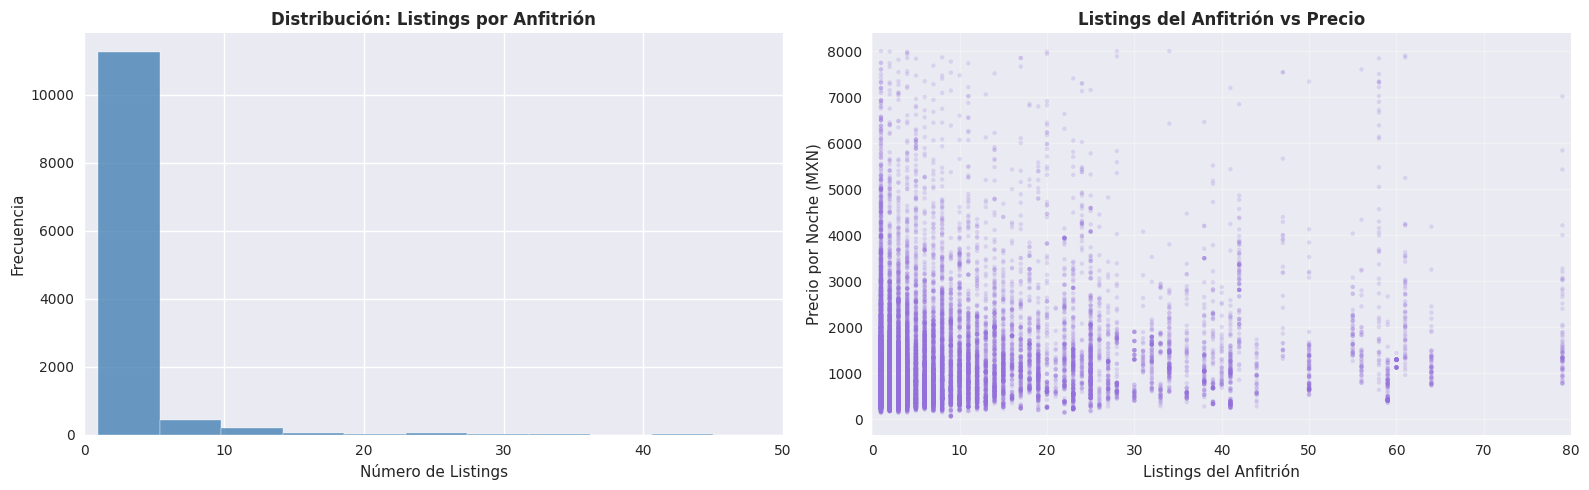

In [34]:
# Distribución: cantidad de listings por anfitrión
listings_por_host = data.groupby('host_id')['id'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(listings_por_host, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución: Listings por Anfitrión', fontweight='bold')
axes[0].set_xlabel('Número de Listings')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(0, 50)

# Scatter: listings del anfitrión vs precio
data_plot2 = data[data['price'] <= 8000].dropna(subset=['price'])
axes[1].scatter(data_plot2['calculated_host_listings_count'], data_plot2['price'],
                alpha=0.2, s=10, color='mediumpurple', edgecolors='none')
axes[1].set_xlabel('Listings del Anfitrión')
axes[1].set_ylabel('Precio por Noche (MXN)')
axes[1].set_title('Listings del Anfitrión vs Precio', fontweight='bold')
axes[1].set_xlim(0, 80)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 13. Resumen y Conclusiones del EDA

In [35]:
print('=' * 65)
print('RESUMEN EDA — AIRBNB LISTINGS CDMX')
print('=' * 65)

print(f'''
1. TAMAÑO Y ESTRUCTURA
   - {len(data):,} listings, 18 variables.
   - Variables numéricas: {len(vars_num_analisis)}
   - Variables categóricas útiles: {len(vars_cat_analisis)}
   - Columnas vacías (100% nulos): neighbourhood_group, license → eliminar.

2. VARIABLE OBJETIVO: price
   - Media: ${data['price'].mean():,.0f} MXN | Mediana: ${data['price'].median():,.0f} MXN
   - Fuertemente sesgada a la derecha (skew = {data['price'].skew():.2f}).
   - Se recomienda transformación logarítmica (log(price)) para modelado.
   - {data['price'].isnull().sum():,} registros sin precio ({data['price'].isnull().mean()*100:.1f}%).

3. VALORES ATÍPICOS
   - 1,768 registros con precio fuera del rango IQR (> $3,063 MXN/noche).
   - Precios máximos: hasta $900,000 MXN/noche (probablemente errores).
   - minimum_nights también tiene outliers extremos (hasta 1,125 noches).

4. DATOS FALTANTES
   - price: 12.9% | last_review y reviews_per_month: 12.6% (correlacionados).
   - Listings sin ninguna reseña → reviews_per_month es NaN naturalmente.

5. CORRELACIÓN CON price
   - Ninguna variable numérica tiene correlación fuerte con price.
   - Las correlaciones de Pearson son bajas (<|0.05|), indicando relaciones no lineales.
   - Spearman muestra valores ligeramente mayores pero igualmente bajos.
   - El tipo de habitación (room_type) y la alcaldía tienen mayor impacto explicativo.

6. CATEGORÍAS IMPORTANTES
   - room_type: 65.4% son "Entire home/apt" con precio medio de ~$1,930 MXN.
   - Alcaldía con mayor precio promedio: Tlalpan ($2,493), Cuajimalpa ($2,151), Cuauhtémoc ($2,126).
   - Cuauhtémoc concentra el 46.3% de todos los listings.

7. RECOMENDACIONES PARA MODELADO
   - Aplicar log(price) para normalizar la variable objetivo.
   - Imputar price con KNN o IterativeImputer (más robusto que media/mediana).
   - Codificar room_type y neighbourhood con one-hot o target encoding.
   - Considerar eliminar outliers extremos de price (>$15,000) antes de modelar.
   - Latitude y longitude pueden incluirse como features geoespaciales.
''')

RESUMEN EDA — AIRBNB LISTINGS CDMX

1. TAMAÑO Y ESTRUCTURA
   - 27,051 listings, 18 variables.
   - Variables numéricas: 9
   - Variables categóricas útiles: 2
   - Columnas vacías (100% nulos): neighbourhood_group, license → eliminar.

2. VARIABLE OBJETIVO: price
   - Media: $1,793 MXN | Mediana: $1,039 MXN
   - Fuertemente sesgada a la derecha (skew = 52.12).
   - Se recomienda transformación logarítmica (log(price)) para modelado.
   - 3,484 registros sin precio (12.9%).

3. VALORES ATÍPICOS
   - 1,768 registros con precio fuera del rango IQR (> $3,063 MXN/noche).
   - Precios máximos: hasta $900,000 MXN/noche (probablemente errores).
   - minimum_nights también tiene outliers extremos (hasta 1,125 noches).

4. DATOS FALTANTES
   - price: 12.9% | last_review y reviews_per_month: 12.6% (correlacionados).
   - Listings sin ninguna reseña → reviews_per_month es NaN naturalmente.

5. CORRELACIÓN CON price
   - Ninguna variable numérica tiene correlación fuerte con price.
   - Las correl